# 04 — CUT&RUN: BRD4 at Il1b Peaks

This notebook supports **Fig. 4H–I** in the study by connecting **BRD4 chromatin occupancy** to the **Il1b enhancer peak set**.

In the experiment, **Cx3cr1+ cells** are FACS-sorted from mice and assayed with **anti-FLAG CUT&RUN** in a **BRD4-Flag** strain (BRD4 sits at enhancer DNA where it can recruit/coordinate transcriptional programs). The key comparison is:

- **Sham vs TAC** (baseline vs aortic constriction injury)

**Genome:** **mm10 (GRCm38)**.

**Readout here:** compare BRD4 (ChIP-like CUT&RUN enrichment) at the paper’s **Il1b enhancer peaks 1–7**.

Note: this notebook describes the **workflow + bookkeeping**; the heavy lifting (QC, alignment, peak calling, bigWig tracks) is handled by **`nf-core/cutandrun`** as outlined in `STUDY_ANALYSIS_AND_REPLICATION_ROADMAP.md`. 

## Data (BRD4 CUT&RUN + IgG control)

The download script (`scripts/python/download_data.py`) fetches 4 CUT&RUN accessions under GEO **GSE221699**:

- **SRR22882106** — `Sham_CX3CR1pos_FLAG` (BRD4-target)
- **SRR22882107** — `TAC1_CX3CR1pos_FLAG` (BRD4-target)
- **SRR22882108** — `TAC2_CX3CR1pos_FLAG` (BRD4-target)
- **SRR22882109** — `TAC2_CX3CR1neg_IgG` (IgG control; used as the background/control group for peak calling)

`nf-core/cutandrun` expects a **samplesheet** with one row per FASTQ pair and a **control** group name that points to the IgG rows.

If you didn’t download CUT&RUN yet, run:

- `python scripts/python/download_data.py`

from the project root (ARM64 is fine for this step).

## Pipeline (what this notebook sets up)

The **analysis proper** is done by `nf-core/cutandrun` (Nextflow). Conceptually the steps are:

1. **Prepare samplesheet** (`design_matrix.csv` / `samplesheet.csv`)
   - columns: `group, replicate, fastq_1, fastq_2, control`
   - BRD4-Flag samples are assigned to `Sham` and `TAC`
   - IgG sample is assigned to a control group (e.g. `igg_ctrl`)
2. **Run `nf-core/cutandrun`**
   - alignment to **mm10 / GRCm38**
   - QC + (de-)duplication rules (by default: de-dup on control samples)
   - peak calling (defaults include **SEACR** or **MACS2** depending on pipeline settings)
   - export **peaks** + **bigWig** tracks for coverage
3. **Il1b locus visualization**
   - focus window around the Il1b enhancer region (paper-relevant locus)
   - inspect/compare peak “1–7” intervals with the **BRD4** bigWig signal (Sham vs TAC)

The Il1b locus window used for quick inspection is approximately:

- **mm10 chr2:129.3–129.4 Mb** (see `STUDY_ANALYSIS_AND_REPLICATION_ROADMAP.md` for the lift target used later).

After the pipeline finishes, you can plot tracks in IGV/UCSC or use the pipeline-generated coverage outputs for R plotting.

### Step 0: sanity-check data and create the CUT&RUN samplesheet

`nf-core/cutandrun` needs an input samplesheet (CSV) with columns:

- `group` (experimental group name)
- `replicate` (integer replicate id within that group)
- `fastq_1`, `fastq_2` (full paths to gzipped FASTQs)
- `control` (the *group* name used for the control rows)

For this dataset:

- BRD4-Flag samples -> `group` = `Sham` or `TAC`
- IgG sample -> `group` = `igg_ctrl`
- The `control` column for `Sham` and `TAC` points to `igg_ctrl`

Run the next cell once you have FASTQs downloaded under `data/<SRR>/`.

In [6]:
# Create nf-core/cutandrun samplesheet (CSV) from downloaded CUT&RUN FASTQs
# Expected output columns: group,replicate,fastq_1,fastq_2,control

srr_to_row <- data.frame(
  group = c("Sham", "TAC", "TAC", "igg_ctrl"),
  replicate = c(1, 1, 2, 1),
  srr = c("SRR22882106", "SRR22882107", "SRR22882108", "SRR22882109"),
  # For control samples, nf-core expects the control column to be blank (not the string "NA").
  control = c("igg_ctrl", "igg_ctrl", "igg_ctrl", ""),
  stringsAsFactors = FALSE
)

# Support running either from repo root or notebooks/.
project_root <- if (dir.exists("data") && dir.exists("scripts")) {
  normalizePath(".", winslash = "/", mustWork = TRUE)
} else if (dir.exists("../data") && dir.exists("../scripts")) {
  normalizePath("..", winslash = "/", mustWork = TRUE)
} else {
  stop("Could not locate project root (expected data/ and scripts/)")
}

data_dir <- file.path(project_root, "data")

get_fastq <- function(run_id, mate) {
  d <- file.path(data_dir, run_id)
  if (!dir.exists(d)) return(NA_character_)

  fqs <- list.files(d, pattern = "\\.fastq\\.gz$", full.names = TRUE)
  if (length(fqs) == 0) return(NA_character_)

  # Prefer the conventional *_1.fastq.gz / *_2.fastq.gz naming.
  pref <- basename(fqs)
  pat1 <- if (mate == 1) "\\_1\\.fastq\\.gz$" else "\\_2\\.fastq\\.gz$"
  pick <- fqs[grep(pat1, pref)]
  if (length(pick) == 0) {
    # Fallback: 1.fastq.gz / 2.fastq.gz in filename.
    pat2 <- if (mate == 1) "1\\.fastq\\.gz$" else "2\\.fastq\\.gz$"
    pick <- fqs[grep(pat2, pref)]
  }
  if (length(pick) == 0) pick <- fqs[1]
  normalizePath(pick[[1]], winslash = "/", mustWork = TRUE)
}

srr_to_row$fastq_1 <- vapply(srr_to_row$srr, get_fastq, mate = 1, FUN.VALUE = character(1))
srr_to_row$fastq_2 <- vapply(srr_to_row$srr, get_fastq, mate = 2, FUN.VALUE = character(1))

missing <- srr_to_row[is.na(srr_to_row$fastq_1) | is.na(srr_to_row$fastq_2), c("group", "replicate", "srr")]
if (nrow(missing) > 0) {
  stop("Missing FASTQ pairs for:\n", paste(apply(missing, 1, paste, collapse = ", "), collapse = "\n"))
}

out_dir <- file.path(project_root, "output", "cutandrun")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

out_path <- file.path(out_dir, "design_matrix.csv")
write.csv(
  srr_to_row[, c("group", "replicate", "fastq_1", "fastq_2", "control")],
  file = out_path,
  row.names = FALSE,
  quote = FALSE
)

cat("Wrote:", out_path, "\n")
print(srr_to_row[, c("group", "replicate", "srr", "control")])


Wrote: /home/steve/Projects/MCELLBIX110-122 Immunology/Chromatin Remodeling Drives Immune-Fibroblast Crosstalk in Heart Failure Pathogenesis/chromatin-hf-crosstalk/output/cutandrun/design_matrix.csv 
     group replicate         srr  control
1     Sham         1 SRR22882106 igg_ctrl
2      TAC         1 SRR22882107 igg_ctrl
3      TAC         2 SRR22882108 igg_ctrl
4 igg_ctrl         1 SRR22882109         


### Step 1: run `nf-core/cutandrun`

Once `design_matrix.csv` exists (from Step 0), run the Nextflow pipeline from the **project root**:

```bash
nextflow run nf-core/cutandrun \
  --genome GRCm38 \
  --input output/cutandrun/design_matrix.csv \
  --outdir output/cutandrun/nfcore \
  -profile singularity \
  --peakcaller MACS2
```

Notes:
- `--input` points to the CSV created in this notebook.
- `--genome GRCm38` matches **mm10 / mouse reference**.
- The pipeline handles alignment, QC, (optional) deduplication logic, peak calling, and track export.
- Peak “1–7” is a *paper-defined label set*. After the run, use the called peaks BED files + the paper’s Il1b peak coordinates to identify which intervals correspond to peaks 1–7.

### Step 2: focus on the Il1b locus and interpret “peaks 1–7”

`CUT&RUN` BRD4-Flag signal should be enriched at the **Il1b enhancer** region for **TAC vs Sham** in **Cx3cr1+** cells.

For quick locus inspection, you can plot/inspect tracks around the Il1b region. In this project, the Il1b locus window used for plotting is approximately:

- **mm10 chr2:129.3–129.4 Mb** (see `STUDY_ANALYSIS_AND_REPLICATION_ROADMAP.md`)

Practical approach after `nf-core/cutandrun`:

- Open the pipeline-produced **peak BED** files and locate the enhancer intervals inside the Il1b window.
- Map those intervals to the paper’s “peaks 1–7” either by (a) matching coordinates from the paper/supplement, or (b) ranking/ordering the peaks within the window and using the reported Peak 5/6 focus (CRISPR validation).

For visualization, you can use IGV/UCSC with the pipeline-exported bigWig coverage.

### Step 3: what success looks like

After a successful run, you should have (typically under your `--outdir`):

- **QC reports** (FASTQ QC, alignment stats)
- **Peak files** (BED) for BRD4 target and appropriate background/control handling
- **bigWig coverage tracks** for Sham and TAC so you can compare signal around Il1b

Sanity checks before you interpret biology:

- Sham bigWig shows baseline BRD4 occupancy at Il1b.
- TAC bigWig shows stronger BRD4 enrichment at the enhancer peaks.
- Peaks within “Il1b Peaks 1–7” correspond to enhancer-like intervals (away from the gene body/TSS), consistent with the paper’s enhancer narrative.

### Step 4: interpret copied pipeline outputs (local)

After `nf-core/cutandrun` finishes (and you copy `output/cutandrun/` to this machine), the useful paths are:

| Content | Location (under `output/cutandrun/nfcore/`) |
|--------|---------------------------------------------|
| **MACS2 peaks** (per sample) | `03_peak_calling/04_called_peaks/macs2/*.macs2.peaks.cut.bed` |
| **Consensus peaks** (by group) | `03_peak_calling/05_consensus_peaks/*.macs2.consensus*.bed` |
| **bigWig coverage** | `03_peak_calling/03_bed_to_bigwig/*.bigWig` |
| **MultiQC** | `04_reporting/multiqc/multiqc_report.html` |
| **IGV session** (optional) | `04_reporting/igv/igv_session.xml` |

BED files from this pipeline use **numeric** chromosome names (`1`, `2`, …) as in Ensembl-style references. The Il1b neighborhood on **mm10** is on **chr2** → seqname **`2`**.

The next code cell loads peaks overlapping an **Il1b-centric window** and summarizes **mean bigWig signal** plus **log2(mean / IgG)** in that window. Raw means are **not** IgG-corrected by the pipeline; comparing BRD4 to IgG in the same window is a minimal sanity check. The paper’s **“peaks 1–7”** labels still require coordinates from the publication or supplement. Adjust `il1b_start` / `il1b_end` if needed (or inspect **IGV** using `04_reporting/igv/igv_session.xml`).

Il1b window (mm10): 2:129280000-129400000

# A tibble: 4 × 3
  label       mean_signal log2_vs_igg
  <chr>             <dbl>       <dbl>
1 Sham_R1           0.113      -1.49 
2 TAC_R1            0.205      -0.640
3 TAC_R2            0.493       0.627
4 igg_ctrl_R1       0.319       0    

Raw means are pipeline-scaled coverage, not IgG-subtracted — IgG can be higher than BRD4 in a window.
log2_vs_igg is a simple window-level enrichment vs IgG (pseudocount 1e-6).



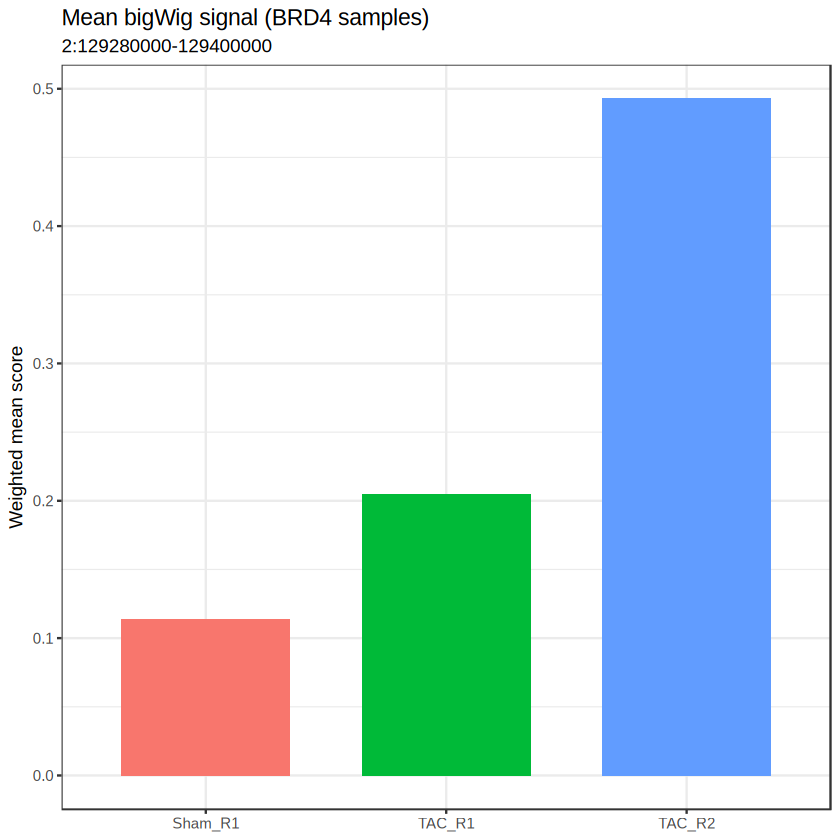


Peaks overlapping Il1b window (per sample):
Sham_R1  TAC_R1  TAC_R2 
      1       0       0 

Example overlaps (first sample):
  seqnames     start       end width strand                   name score
1        2 129297658 129297830   173      * Sham_R1.macs2_peak_815    20

--- How to read peak counts ---
MACS2 reports discrete peaks; diffuse BRD4 signal can raise bigWig without a peak in this exact window.
If TAC peaks = 0 but signal is high, widen the window slightly or inspect IGV (04_reporting/igv/).


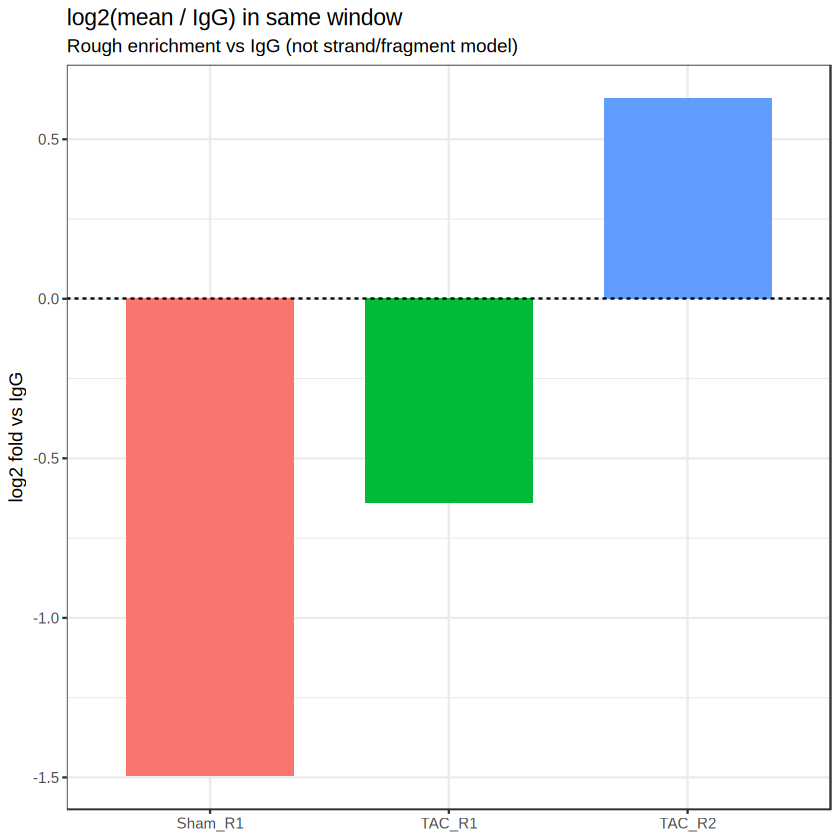

In [7]:
# Summarize BRD4 CUT&RUN signal in an Il1b-centric window (requires GenomicRanges + rtracklayer)
suppressPackageStartupMessages({
  library(GenomicRanges)
  library(rtracklayer)
  library(ggplot2)
  library(dplyr)
})

project_root <- if (dir.exists("data") && dir.exists("scripts")) {
  normalizePath(".", winslash = "/", mustWork = TRUE)
} else if (dir.exists("../data") && dir.exists("../scripts")) {
  normalizePath("..", winslash = "/", mustWork = TRUE)
} else {
  stop("Could not locate project root (expected data/ and scripts/)")
}

nfcore_dir <- file.path(project_root, "output", "cutandrun", "nfcore")
peaks_dir <- file.path(nfcore_dir, "03_peak_calling", "04_called_peaks", "macs2")
bw_dir <- file.path(nfcore_dir, "03_peak_calling", "03_bed_to_bigwig")

if (!dir.exists(nfcore_dir)) {
  stop("Missing pipeline output: ", nfcore_dir, "\nCopy output/cutandrun/ from the x86 machine first.")
}

# mm10 / GRCm38: Il1b lies on chromosome 2. Pipeline BEDs use numeric seqnames ("2", not "chr2").
# Adjust if you want a different enhancer-focused interval (paper supplement may refine boundaries).
il1b_start <- 129280000L
il1b_end <- 129400000L
il1b_win <- GRanges("2", IRanges(il1b_start, il1b_end))

mean_bw_in_region <- function(bigwig_path, gr) {
  if (!file.exists(bigwig_path)) return(NA_real_)
  x <- import(bigwig_path, which = gr)
  if (length(x) == 0) return(NA_real_)
  sc <- mcols(x)$score
  if (is.null(sc)) return(NA_real_)
  weighted.mean(as.numeric(sc), width(x))
}

target_bws <- tibble::tibble(
  label = c("Sham_R1", "TAC_R1", "TAC_R2", "igg_ctrl_R1"),
  path = file.path(bw_dir, paste0(label, ".bigWig"))
)

target_bws <- target_bws %>%
  mutate(mean_signal = vapply(path, mean_bw_in_region, numeric(1), gr = il1b_win))

igg_mean <- target_bws$mean_signal[target_bws$label == "igg_ctrl_R1"]
target_bws <- target_bws %>%
  mutate(log2_vs_igg = log2((mean_signal + 1e-6) / (igg_mean + 1e-6)))

cat("Il1b window (mm10): 2:", il1b_start, "-", il1b_end, "\n\n", sep = "")
print(target_bws %>% select(label, mean_signal, log2_vs_igg))
cat(
  "\nRaw means are pipeline-scaled coverage, not IgG-subtracted — IgG can be higher than BRD4 in a window.\n",
  "log2_vs_igg is a simple window-level enrichment vs IgG (pseudocount 1e-6).\n\n",
  sep = ""
)

p_raw <- ggplot(
  target_bws %>% filter(label != "igg_ctrl_R1"),
  aes(x = label, y = mean_signal, fill = label)
) +
  geom_col(width = 0.7, show.legend = FALSE) +
  labs(
    title = "Mean bigWig signal (BRD4 samples)",
    subtitle = paste0("2:", il1b_start, "-", il1b_end),
    x = NULL,
    y = "Weighted mean score"
  ) +
  theme_bw()

p_enr <- ggplot(
  target_bws %>% filter(label != "igg_ctrl_R1"),
  aes(x = label, y = log2_vs_igg, fill = label)
) +
  geom_col(width = 0.7, show.legend = FALSE) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "log2(mean / IgG) in same window",
    subtitle = "Rough enrichment vs IgG (not strand/fragment model)",
    x = NULL,
    y = "log2 fold vs IgG"
  ) +
  theme_bw()

print(p_raw)
print(p_enr)

# MACS2 peaks overlapping the same window (target samples only)
peak_files <- file.path(
  peaks_dir,
  c("Sham_R1.macs2.peaks.cut.bed", "TAC_R1.macs2.peaks.cut.bed", "TAC_R2.macs2.peaks.cut.bed")
)
names(peak_files) <- c("Sham_R1", "TAC_R1", "TAC_R2")

peak_tables <- lapply(names(peak_files), function(nm) {
  p <- import(peak_files[[nm]], format = "BED")
  hits <- subsetByOverlaps(p, il1b_win, type = "any")
  as.data.frame(hits)
})
names(peak_tables) <- names(peak_files)

cat("\nPeaks overlapping Il1b window (per sample):\n")
print(sapply(peak_tables, nrow))

cat("\nExample overlaps (first sample):\n")
print(head(peak_tables[["Sham_R1"]]))

cat(
  "\n--- How to read peak counts ---\n",
  "MACS2 reports discrete peaks; diffuse BRD4 signal can raise bigWig without a peak in this exact window.\n",
  "If TAC peaks = 0 but signal is high, widen the window slightly or inspect IGV (04_reporting/igv/).\n",
  sep = ""
)

### Interpretation of current output

From the saved run in this notebook:

- Window: `2:129280000-129400000`.
- Raw window means: `Sham_R1=0.113`, `TAC_R1=0.205`, `TAC_R2=0.493`, `IgG=0.319`.
- Peak overlaps in this exact window: `Sham_R1=1`, `TAC_R1=0`, `TAC_R2=0`.

How to read this:

1. **Raw means are not background-corrected.** The bigWig means are scaled coverage values; they are not IgG-subtracted. So `IgG > Sham` in this window can happen.
2. **TAC signal looks heterogeneous.** `TAC_R2` is clearly higher than `TAC_R1`, suggesting replicate variability (biological and/or technical).
3. **No TAC MACS2 peak in this exact interval does not necessarily mean no TAC signal.** MACS2 calls discrete local peaks; signal can be broad, shifted, or just below threshold in this specific window.

Most likely conclusion at this stage:

- The chosen Il1b window captures at least one discrete Sham peak and non-uniform TAC coverage.
- This is **not yet sufficient** to claim stronger BRD4 enrichment in TAC at paper-defined "peaks 1-7".

Recommended next checks (same notebook workflow):

- Re-run the updated Step 4 code cell (it now reports `log2_vs_igg`) so interpretation uses background-relative values.
- In IGV (`output/cutandrun/nfcore/04_reporting/igv/igv_session.xml`), inspect slightly wider bounds around this locus (e.g. +/-50-100 kb).
- Match against paper/supplement Il1b peak coordinates, then quantify those exact intervals rather than one broad window.
- If needed, add formal differential binding (e.g. csaw/diffBind) across replicates for a statistical conclusion.